# Criando database para SQL 

## Importando infosiga.db

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

con = sqlite3.connect("../data/processed/infosiga.db")

pd.read_parquet("../data/processed/pessoas.parquet").to_sql("pessoas", con, if_exists="replace", index=False)
pd.read_parquet("../data/processed/sinistros.parquet").to_sql("sinistros", con, if_exists="replace", index=False)
pd.read_parquet("../data/processed/veiculos.parquet").to_sql("veiculos", con, if_exists="replace", index=False)

for tabela in ["pessoas", "sinistros", "veiculos"]:
    print(tabela, pd.read_sql(f"SELECT COUNT(*) as n FROM {tabela}", con))

print("Banco criado: infosiga.db")

## Pergunta 1

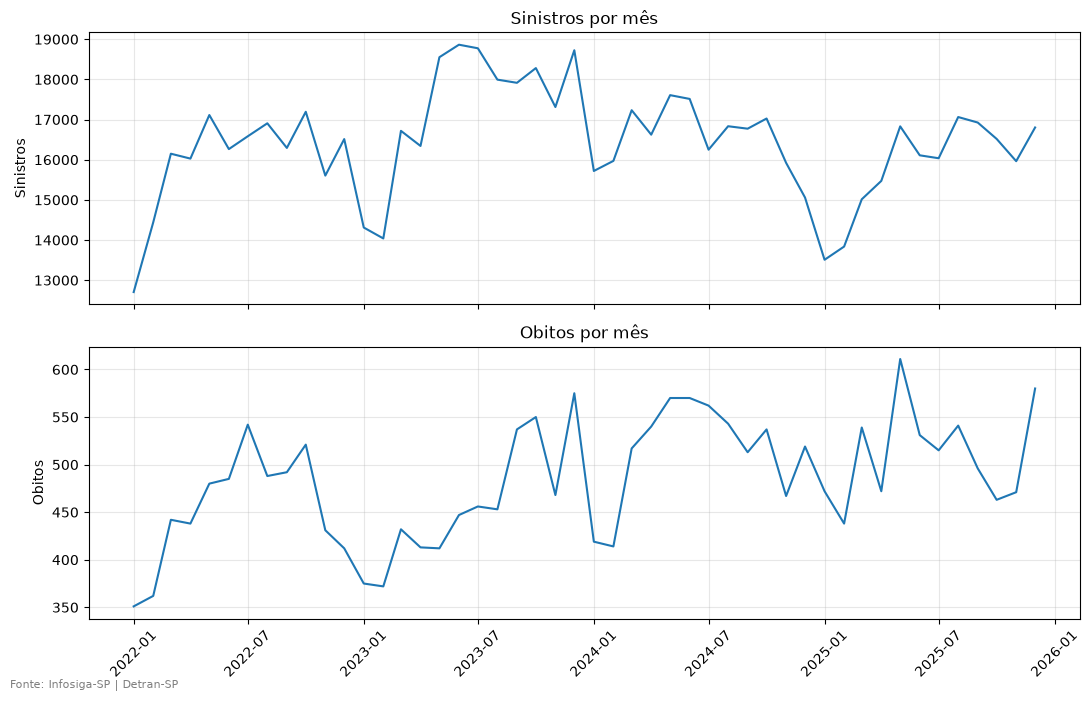

In [42]:

pergunta_um = pd.read_sql(
"""
SELECT s.mes_sinistros AS mes_ano, s.total_sinistros, p.total_obitos,
    ROUND(100.0  * p.total_obitos / s.total_sinistros, 1) AS pct
FROM
    (
    SELECT strftime('%Y-%m', data_sinistro) AS mes_sinistros, COUNT(*) AS total_sinistros
    FROM sinistros
    GROUP BY strftime('%Y-%m', data_sinistro)
    ) s
LEFT JOIN
    (
     SELECT strftime('%Y-%m', data_sinistro) AS mes_obitos, COUNT(*) AS total_obitos
     FROM pessoas
     WHERE gravidade_lesao = 'FATAL'
     GROUP BY strftime('%Y-%m', data_sinistro)
    ) p
ON s.mes_sinistros = p.mes_obitos
ORDER BY mes_ano 
""", con
)

pergunta_um["mes_ano"] = pd.to_datetime(pergunta_um["mes_ano"], format="%Y-%m")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# sinistros
ax1.plot(pergunta_um["mes_ano"], pergunta_um["total_sinistros"])
ax1.set_title("Sinistros por mês")
ax1.set_ylabel("Sinistros")
ax1.grid(alpha=0.3)

ax2.plot(pergunta_um["mes_ano"], pergunta_um["total_obitos"])
ax2.set_title("Obitos por mês")
ax2.set_ylabel("Obitos")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(alpha=0.3)

fig.text(0.01, 0.01, "Fonte: Infosiga-SP | Detran-SP", fontsize=8, color="gray")

plt.tight_layout()

plt.savefig("../reports/figures/01_evolucao_mensal.png", dpi=150, bbox_inches="tight")

plt.show()

## perguntas 3  

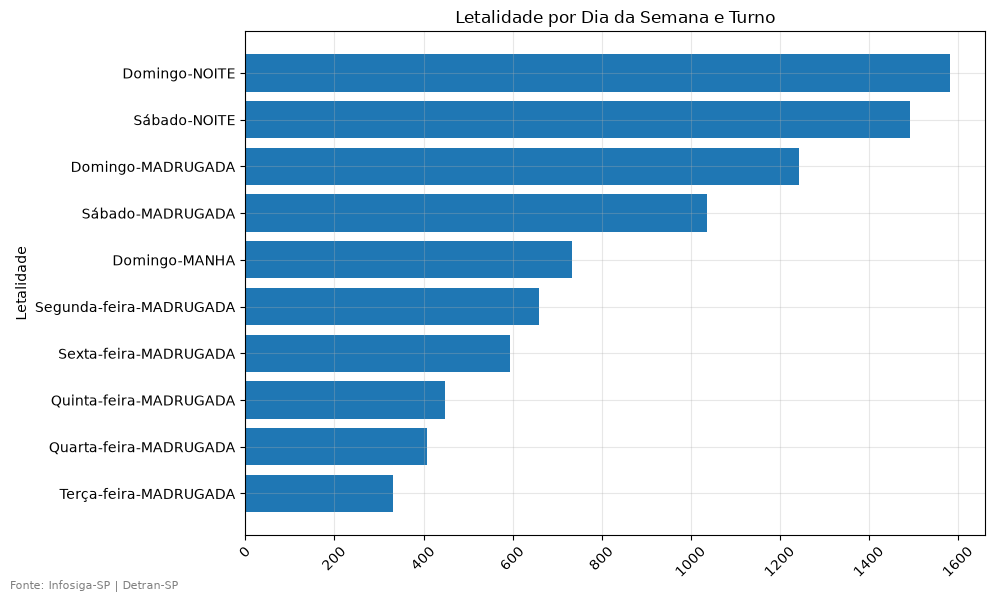

In [43]:

pergunta_dois = pd.read_sql(
"""
SELECT s.dia_da_semana, s.turno, s.sinistros, 
	COALESCE(p.mortes, 0) AS mortes,
	ROUND(100.0 * COALESCE(p.mortes, 0) / s.sinistros, 1) AS mortes_por_cem
FROM 
    (SELECT dia_da_semana, turno, COUNT(*) AS sinistros
    FROM sinistros
    GROUP BY dia_da_semana, turno
	) s
LEFT JOIN
	(
	SELECT si.dia_da_semana, si.turno, COUNT(*) AS mortes
	FROM pessoas p
	JOIN sinistros si
	ON p.id_sinistro = si.id_sinistro 
	WHERE p.gravidade_lesao = 'FATAL'
	GROUP BY si.dia_da_semana, si.turno
	) p
ON s.dia_da_semana  = p.dia_da_semana  
AND s.turno = p.turno 
WHERE s.turno <> 'NAO DISPONIVEL'
  AND s.sinistros >= 1000
ORDER BY mortes_por_cem DESC
LIMIT 10;
""", con)

pergunta_dois = pergunta_dois.sort_values("mortes", ascending=True)
pergunta_dois["rotulo"] = pergunta_dois["dia_da_semana"] + "-" + pergunta_dois["turno"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(pergunta_dois["rotulo"], pergunta_dois["mortes"])
ax.set_title("Letalidade por Dia da Semana e Turno")
ax.set_ylabel("Letalidade")
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=45)

fig.text(0.01, 0.01, "Fonte: Infosiga-SP | Detran-SP", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("../reports/figures/02_letalidade_semana_turno.png", dpi=150, bbox_inches="tight")

plt.show()


## pergunta 4

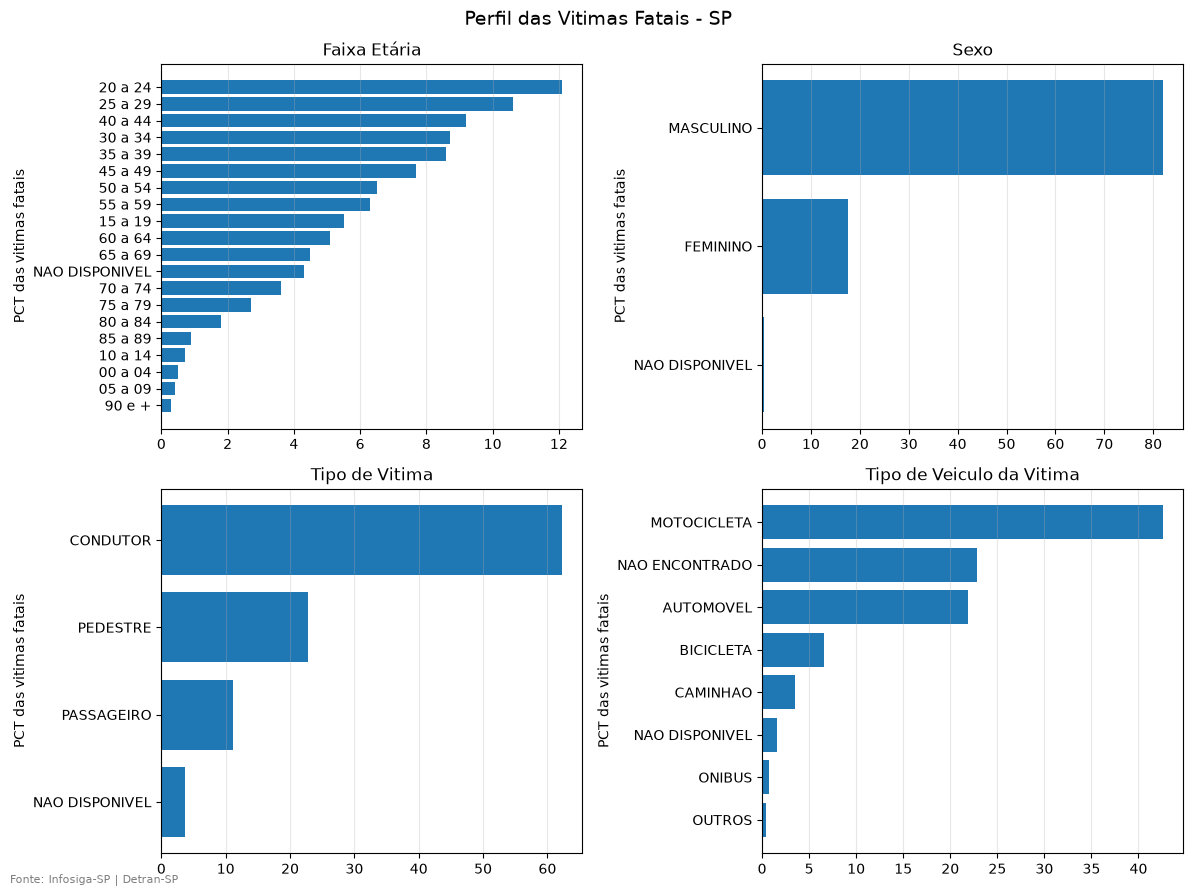

In [44]:

faixa_etaria = pd.read_sql(
"""
-- porcentagem de faixa etaria
SELECT faixa_etaria_demografica, 
	COUNT(*) AS mortes,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM pessoas
WHERE gravidade_lesao = 'FATAL' AND 
faixa_etaria_demografica IS NOT NULL
GROUP BY faixa_etaria_demografica
ORDER BY mortes DESC
""", con)

sexo = pd.read_sql(
""" 
SELECT sexo, 
	COUNT(*) AS total, 
	ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM pessoas
WHERE gravidade_lesao = 'FATAL'
GROUP BY sexo
ORDER BY pct DESC;
""", con)

tipo_de_vitima = pd.read_sql(
""" 
-- porcentagem tipo de vitima
SELECT tipo_de_vitima, 
	COUNT(*) AS total, 
	ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM pessoas
WHERE gravidade_lesao = 'FATAL'
GROUP BY tipo_de_vitima 
ORDER BY pct DESC;
""", con)

veiculo = pd.read_sql(
"""
SELECT tipo_veiculo_vitima, 
    COUNT(*) AS total, 
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM pessoas
WHERE gravidade_lesao = 'FATAL'
GROUP BY tipo_veiculo_vitima 
ORDER BY pct DESC;
""", con)

def plotar_barras(ax, tabela, coluna, titulo):
	dados = tabela.fillna({coluna : "NAO ENCONTRADO"})
	dados = dados.sort_values("pct", ascending=True)
	ax.barh(dados[coluna].astype(str), dados["pct"])
	ax.set_title(titulo)
	ax.set_ylabel("PCT das vitimas fatais")
	ax.grid(axis="x", alpha=0.3)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))

plotar_barras(ax1, faixa_etaria, "faixa_etaria_demografica", "Faixa Etária")
plotar_barras(ax2, sexo, "sexo", "Sexo")
plotar_barras(ax3, tipo_de_vitima, "tipo_de_vitima", "Tipo de Vitima")
plotar_barras(ax4, veiculo, "tipo_veiculo_vitima", "Tipo de Veiculo da Vitima")

fig.suptitle("Perfil das Vitimas Fatais - SP", fontsize=14)
fig.text(0.01, 0.01, "Fonte: Infosiga-SP | Detran-SP", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("../reports/figures/03_perfil_frequente.png", dpi=150, bbox_inches="tight")
plt.show()

## Pergunta 5

              tipo_via tp_sinistro_primario  dia_da_semana      turno  \
9         VIAS URBANAS               CHOQUE        Domingo  MADRUGADA   
8         VIAS URBANAS               CHOQUE  Segunda-feira  MADRUGADA   
7         VIAS URBANAS               CHOQUE    Sexta-feira  MADRUGADA   
6  ESTRADAS E RODOVIAS              COLISAO         Sábado  MADRUGADA   
5  ESTRADAS E RODOVIAS              COLISAO    Sexta-feira  MADRUGADA   

   total_sinistros  total_obitos    pct  \
9             1740           292  16.78   
8              750           129  17.20   
7              597           103  17.25   
6              856           173  20.21   
5              604           127  21.03   

                                            conjunto  
9              VIAS URBANAS-CHOQUE-Domingo-MADRUGADA  
8        VIAS URBANAS-CHOQUE-Segunda-feira-MADRUGADA  
7          VIAS URBANAS-CHOQUE-Sexta-feira-MADRUGADA  
6       ESTRADAS E RODOVIAS-COLISAO-Sábado-MADRUGADA  
5  ESTRADAS E RODOVIAS-COLI

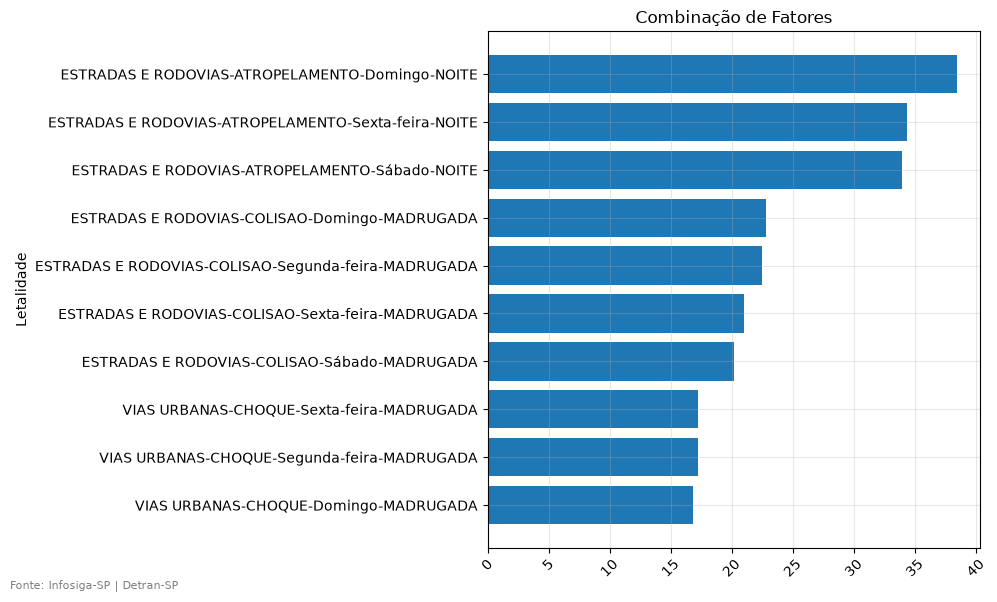

In [52]:
combinacao_fatores = pd.read_sql(
"""
    SELECT si.tipo_via, si.tp_sinistro_primario, 
	si.dia_da_semana, si.turno, si.total_sinistros, so.total_obitos,
	ROUND(100.0 * so.total_obitos / si.total_sinistros, 2) AS pct
FROM (
	SELECT si.tipo_via, si.tp_sinistro_primario, si.dia_da_semana, si.turno, COUNT(*) AS total_obitos
	FROM sinistros si
	LEFT JOIN pessoas p
	ON si.id_sinistro = p.id_sinistro  
	WHERE p.gravidade_lesao = 'FATAL'
	GROUP BY si.tipo_via, si.tp_sinistro_primario, si.dia_da_semana, si.turno
	) so
RIGHT JOIN 
	(
	SELECT si.tipo_via, si.tp_sinistro_primario, si.dia_da_semana, si.turno, COUNT(*) AS total_sinistros
	FROM sinistros si
	GROUP BY si.tipo_via, si.tp_sinistro_primario, si.dia_da_semana, si.turno
	) si
ON so.tipo_via = si.tipo_via
AND so.tp_sinistro_primario = si.tp_sinistro_primario
AND so.dia_da_semana = si.dia_da_semana 
AND so.turno = si.turno 
WHERE si.tp_sinistro_primario <> 'NAO INFORMADO'
AND si.turno <> 'NAO DISPONIVEL'
AND si.total_sinistros >= 500
ORDER BY pct DESC
LIMIT 10;
""", con
)

combinacao_fatores["conjunto"] = combinacao_fatores["tipo_via"] + "-" + combinacao_fatores["tp_sinistro_primario"] + "-" + \
    combinacao_fatores["dia_da_semana"] + "-" + combinacao_fatores["turno"]
combinacao_fatores = combinacao_fatores.sort_values("pct", ascending=True)
print(combinacao_fatores.head())

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(combinacao_fatores["conjunto"], combinacao_fatores["pct"])
ax.set_title("Combinação de Fatores")
ax.set_ylabel("Letalidade")
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=45)

fig.text(0.01, 0.01, "Fonte: Infosiga-SP | Detran-SP", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("../reports/figures/04_combinacao_fatores.png", dpi=150, bbox_inches="tight")
plt.show()
